# 11.1. 변분 원리

In [1]:
import numpy as np
from scipy.constants import hbar, m_e, e, h

L = 1e-9
x = np.linspace(0, L, 100001)
E_exact = h**2 / (8 * m_e * L**2) / e


def energy(f):
    df = np.gradient(f, x)
    T = hbar**2 / (2 * m_e) * np.trapezoid(df**2, x)
    N = np.trapezoid(f**2, x)
    return T / N


print(f"참값 : {E_exact:.6f} eV")

for f, name in [(x * (L - x), "x(L-x)"), (x**2 * (L - x) ** 2, "x²(L-x)²"), (np.sin(np.pi * x / L), "sin(πx/L)")]:
    E = energy(f) / e
    print(f"{name:10s} : {E:.6f} eV (오차: {(E - E_exact) / E_exact * 100:+8.4f} %)")

참값 : 0.376030 eV
x(L-x)     : 0.380998 eV (오차:  +1.3212 %)
x²(L-x)²   : 0.457198 eV (오차: +21.5854 %)
sin(πx/L)  : 0.376030 eV (오차:  -0.0000 %)


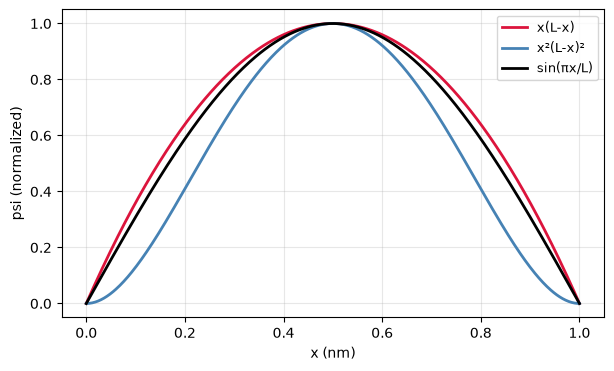

In [2]:
import matplotlib.pyplot as plt

xs = np.linspace(0, L, 500)
fig, ax = plt.subplots(figsize=(7, 4))
for f, name, col in [
    (xs * (L - xs), "x(L-x)", "crimson"),
    (xs**2 * (L - xs) ** 2, "x²(L-x)²", "steelblue"),
    (np.sin(np.pi * xs / L), "sin(πx/L)", "black"),
]:
    ax.plot(xs * 1e9, f / f.max(), lw=2, color=col, label=name)
ax.set_xlabel("x (nm)")
ax.set_ylabel("psi (normalized)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

In [3]:
f = x * (L - x) * np.pi / L**2 + x**2 * (L - x)**2 * (16 - 4 * np.pi) / L**4
E = energy(f) / e
print(f"4차 근사 : {E:.6f} eV (오차: {(E - E_exact) / E_exact * 100:+8.4f} %)")

4차 근사 : 0.376040 eV (오차:  +0.0026 %)
